# General LLM Interview Questions & Answers

---

## Table of Contents

### 1. Embeddings & Representations
- [BERT (Bidirectional Encoder Representations from Transformers)](#bert-bidirectional-encoder-representations-from-transformers)
- [Matryoshka Representation Learning (MRL)](#matryoshka-representation-learning-mrl)

### 2. Model Internals & Architecture
- [Layer Normalization vs. RMS Normalization](#preparation-guide-layer-normalization-vs-rms-normalization)
- [Residual Connections](#residual-connections)
- [RoPE (Rotary Position Embeddings)](#1-the-core-idea-position-dependent-rotations)
- [Scaled Dot-Product Attention](#dot-product-variance-and-softmax-gradients)
- [Decoding Strategies (Greedy, Beam, Top-K, Top-P, Temperature)](#decoding-strategies)
- [Temperature Parameter](#temperature-parameter)

### 3. Retrieval & Search
- [BM25 Ranking Algorithm](#bm25-ranking-algorithm)
- [MRR vs. NDCG (Ranking Evaluation Metrics)](#mean-reciprocal-rank-mrr-vs-ndcg)

### 4. Quantization & Model Formats
- [Symmetric vs. Asymmetric Quantization](#understanding-quantization-in-llms-symmetric-vs-asymmetric)
- [Quantization Step-by-Step Walkthrough](#1-original-tensor)
- [Data Types: FP32, FP16, BF16, INT8](#model-storage-requirements)
- [GGUF Format & llama.cpp](#quantization-with-gguf-and-llamacpp)
- [GGUF File Contents](#the-gguf-ggml-universal-format)
- [Safetensors Format](#safetensors)

### 5. Evaluation Metrics
- [Perplexity (PPL)](#understanding-perplexity-ppl)

### 6. Fine-Tuning & Practical Tips
- [Padding Token in GPT-based Models](#padding-token-in-gpt-based-models)
- [Fine-Tuning Hardware Requirements](#fine-tuning-hardware-requirements)
- [LLM Optimization Strategies](#llm-optimization-strategies)
- [Inference Frameworks (TGI, vLLM, TensorRT-LLM)](#inference-frameworks)

### 7. Quick Reference
- [LLM Terminology Glossary](#quick-reference-llm-terminology-glossary)

---

---

# Section 1: Embeddings & Representations

This section covers how text is represented as vectors -- from foundational models like BERT to advanced techniques like Matryoshka embeddings.

---


# BERT (Bidirectional Encoder Representations from Transformers)

## 1. What is BERT?
![](https://dd486dzm2qvfqq.archive.is/jSgG7/bad97c1ffc336ddbd852ec9b38053eaa1596a26c.webp)
*   **Definition:** BERT stands for **Bidirectional Encoder Representations from Transformers**. It's a highly influential language representation model developed by Google AI.
*   **Core Architecture:** BERT utilizes *only the **Encoder** part* of the standard Transformer architecture.
* ![](https://dd486dzm2qvfqq.archive.is/jSgG7/2b6673ff6e4fa585956e6ce3c65a768c682ca480.webp)
*   **Key Innovation:** Its main strength lies in learning deep **bidirectional** context. Unlike previous models that read text left-to-right or combined left-to-right and right-to-left training, BERT processes the *entire sequence of words at once* during pre-training, allowing it to understand context from both directions simultaneously.
*   **Goal:** To pre-train a model on a massive amount of text data, creating powerful language representations that can then be fine-tuned for various specific NLP tasks (like question answering, sentiment analysis, etc.).

***
**EASY TO REMEMBER EXPLANATION:** Think of BERT as a super-reader that learns language by reading tons of books. But instead of reading left-to-right, it looks at the whole sentence (or paragraph) at once to understand what each word *really* means based on *all* its neighbours, left and right. It uses only the "understanding" part (Encoder) of the Transformer.
***

## 2. How BERT Learns: Pre-training Tasks

BERT is pre-trained on large text corpora using two novel unsupervised tasks:

### 2.1 Masked Language Model (MLM)

*   **Concept:** Instead of predicting the *next* word (like traditional language models), BERT randomly hides (masks) some percentage of the input tokens (words/subwords) and then tries to predict *only those masked tokens* based on the surrounding unmasked context.
*   **Example:**
    *   Original: "The quick brown fox jumps"
    *   Input to BERT: "The `[MASK]` brown fox jumps"
    *   BERT's Goal: Predict that `[MASK]` should be "quick".
*   **Why it's Important:** This forces the model to fuse context from *both left and right* of the masked word to make a good prediction. This is how BERT learns **bidirectionality**.

***
**INTERVIEW-READY EXPLANATION (MLM):**
"BERT's primary pre-training task is the Masked Language Model or MLM. Here, about 15% of input tokens are randomly replaced with a special `[MASK]` token. The model's objective is then to predict the original tokens based solely on the surrounding context. This forces the model to learn deep bidirectional representations because it needs context from both sides to accurately fill in the blanks."
***

### 2.2 Next Sentence Prediction (NSP)

*   **Concept:** The model receives two sentences, A and B, and must predict whether sentence B is the *actual* next sentence that followed A in the original text, or just a random sentence from the corpus.
*   **Example:**
    *   **IsNext:** A: "The cat is sitting on the mat." B: "The cat is looking at its owner." -> Predict `True`
    *   **NotNext:** A: "He is wearing a swimsuit." B: "The table is round." -> Predict `False`
*   **Why it's Important:** This task teaches BERT to understand relationships *between sentences*, which is crucial for tasks like Question Answering and Natural Language Inference. (Note: Later models like RoBERTa found NSP less critical than initially thought, but it was part of the original BERT.)

***
**INTERVIEW-READY EXPLANATION (NSP):**
"The second pre-training task for BERT was Next Sentence Prediction (NSP). The model was given pairs of sentences and trained to predict if the second sentence was the actual sentence following the first in the original text. This helped the model understand sentence relationships, important for downstream tasks requiring reasoning across sentences."
***

## 3. BERT Architecture: Encoder-Only with Modifications

While BERT uses Transformer Encoders, it includes specific modifications, especially in the input representation:

### 3.1 Input Embeddings

The final input embedding for each token is the **sum** of three separate embeddings:

1.  **Token Embeddings:** Standard embeddings representing the word or subword token itself.
2.  **Segment Embeddings:** Used to distinguish between different sentences when multiple sentences are fed in as input (e.g., Sentence A vs. Sentence B in the NSP task). All tokens in the first sentence get one segment embedding, and all tokens in the second sentence get another.
3. ![](https://dd486dzm2qvfqq.archive.is/jSgG7/aa236850d7df7f247b87be1f3e9e7bb8d95a17fe.webp)
4.  **Positional Embeddings:** Unlike the original Transformer's fixed sine/cosine embeddings, BERT uses ***learnable*** positional embeddings. The model learns the positional information during training, allowing potentially more flexibility.

### 3.2 Special Tokens

*   **`[CLS]` Token:** A special token added to the **beginning** of every input sequence. The final hidden state corresponding to this token is designed to aggregate the representation of the *entire sequence*. It's typically used as the input to a classifier for sequence-level tasks (like sentiment analysis or NSP).
*   **`[SEP]` Token:** A special token used to **separate** multiple input segments (e.g., between sentence A and sentence B, or between a question and its context paragraph).

### 3.3 BERT Pooler

*   **What it is:** A component added *after* the main Transformer Encoder stack.
*   **Function:** It takes the final hidden state corresponding to the `[CLS]` token and transforms it, typically through a linear layer and a Tanh activation function.
*   **Purpose:** To create a fixed-size output vector representing the entire input sequence, suitable for direct use in classification tasks (`pooled output`).

## 4. Applications and Variants

*   **Fine-Tuning:** The standard way to use BERT is to take the pre-trained model and fine-tune it on a smaller, task-specific labeled dataset (e.g., a dataset for sentiment classification, question answering, named entity recognition).
*   **Domain-Specific BERTs:** Variants have been trained on specialized corpora:
    *   **BioBERT:** For biomedical text.
    *   **ChemBERTa:** For chemical literature/molecular properties.
    *   **SciBERT:** For scientific documents.

This is a fantastic narrative-style explanation of BERT, JD—especially with the practical insights and examples like `[MASK]` prediction, segment embedding for NSP, and the architecture notes. To help turn this into an **interview-prep friendly, structured version**, here's an enhanced version that:

-   Combines **clarity with depth**
    
-   Includes **summary lines**, **2-liner takeaways**, and **interview-style insights**
    
-   Polishes technical flow without changing meaning
 
### 📦 **Applications and BERT Variants**

#### 💡 **Applications**

-   **QA, NER, Sentiment Classification, Summarization, Paraphrasing**
    


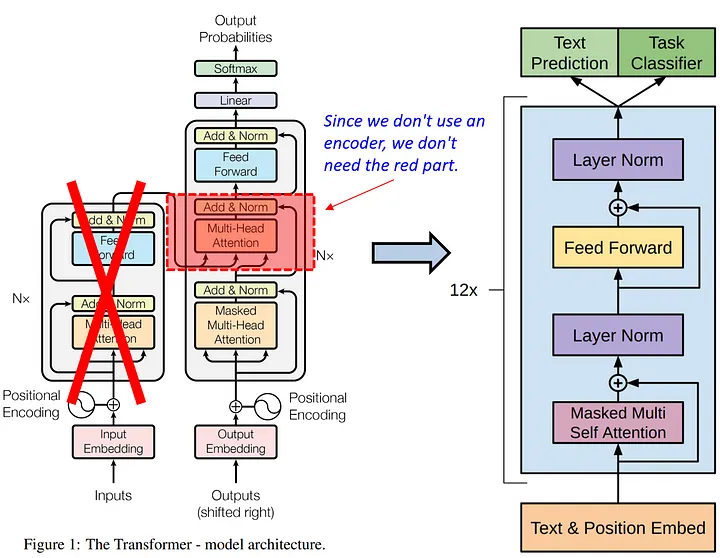

# Matryoshka Representation Learning (MRL)

## 1. What is Matryoshka Representation Learning?

Matryoshka Representation Learning (MRL) is a technique for training machine learning models (often deep neural networks) to produce **nested embeddings**.

### 🔍 **Core Idea**
Instead of training different models or representations for different embedding sizes (e.g., for compression, latency, or memory reasons), this method **trains a single embedding** that supports **multiple granularities**:

> 🧠 **A single large representation vector can be sliced at different lengths**, and each slice retains meaningful, semantically-rich information appropriate to its size.

---
For example, a model trained with MRL might produce a 1024-dimensional embedding vector. The MRL training process ensures that:
*   The full 1024 dimensions form a high-quality representation.
*   The first 512 dimensions *also* form a good (perhaps slightly less accurate) representation.
*   The first 256 dimensions form a decent representation.
*   The first 128 dimensions form a usable, compact representation.
...and so on, down to a chosen minimum size.

### 📌 **Why it Matters**
In many real-world applications (like retrieval, ranking, or edge devices), we face **constraints on computation or memory**. Matryoshka Representation Learning allows:
- **Flexible deployment** — use longer embeddings on powerful servers and shorter ones on edge devices.
- **Progressive compression** — trade-off between performance and resource usage dynamically.
- **Efficient training** — no need to retrain for each dimensionality.

---

### ⚙️ **How It Works**
1. **Representation Vector**: A full-length vector `z ∈ ℝ^D` is produced by the encoder.
2. **Multiple Slices**: Intermediate vectors `z_k = z[:k]` for `k < D` are used for training/inference.
3. **Multi-scale Supervision**:
   - Each slice `z_k` is supervised (e.g., via contrastive loss, classification, retrieval loss).
   - This forces the model to pack the **most essential information early** in the vector.
4. **Training**: A joint loss over all slices encourages hierarchical information encoding.

---
## 2. Why Use MRL? (Motivation & Benefits)

The primary motivation for MRL is **computational efficiency and flexibility** at deployment time, without needing to train multiple separate models.

*   **Adaptive Computation:** You can choose the embedding dimensionality *after* training, based on the available resources or task requirements.
    *   Use **shorter embeddings** (e.g., 128 dims) for tasks requiring low latency, low memory (like on-device search, quick candidate generation).
    *   Use **longer embeddings** (e.g., 1024 dims) for tasks demanding high accuracy where more computation is acceptable (like server-side final ranking).
*   **Resource Savings:** Reduces the need to train and store multiple models for different performance points. One MRL model serves multiple purposes.
*   **Efficient Systems:** Enables building systems (like large-scale search or recommendation) where an initial candidate pool is generated quickly using small embeddings, and then re-ranked more accurately using larger embeddings from the *same* items.

***Highlight:*** `MRL allows a single model to flexibly trade off accuracy and computational cost (latency, memory, storage) at inference time.`
---

### 📈 Benefits
| Advantage | Explanation |
|----------|-------------|
| 🧩 **Hierarchical Semantics** | Coarse to fine information encoded in order. |
| 📉 **Compression-aware** | Shorter slices still retain semantic integrity. |
| 🔁 **One-shot Training** | No need for separate models per embedding size. |
| 📦 **Deployment Flexibility** | Choose embedding size per resource availability. |

---

### 🧠 Related Concepts
- **Contrastive Learning**: Common loss function used to train embeddings.
- **Multi-resolution Learning**: Matryoshka is a generalization into embeddings.
- **Neural Collapse**: Embedding collapse avoided by supervising multiple slices.


### ✅ Summary (One-liner for Interview)
> Matryoshka Representation Learning creates hierarchical embeddings where lower-dimensional prefixes of a full vector preserve meaningful structure, enabling flexible, efficient deployment.

---

### 🧠 Takeaway
> A single embedding vector can support multiple tasks and memory footprints by encoding essential semantics in early dimensions and fine-grained info in later ones — just like nested Matryoshka dolls.


> **Interview Tip -- Embeddings:** When asked about embeddings in interviews, remember these key contrasts: (1) Static embeddings (Word2Vec, GloVe) assign one vector per word regardless of context. (2) Contextual embeddings (BERT, GPT) produce different vectors depending on surrounding words. (3) For retrieval tasks, mention Matryoshka embeddings as a way to get flexible dimensionality from a single model. (4) Always mention the trade-off between embedding dimension and computational cost.

---

# Section 2: Model Internals & Architecture

Deep dives into the building blocks of Transformer-based LLMs: normalization, positional encoding, attention scaling, residual connections, and decoding strategies.

---


# Preparation Guide: Layer Normalization vs. RMS Normalization

## 1. Why Normalize Activations in Neural Networks?

Before diving into LayerNorm and RMSNorm, let's remember *why* we use normalization techniques in deep learning:

*   **Stabilize Training:** Helps prevent activations from becoming too large (exploding) or too small (vanishing) as they pass through layers.
*   **Speed Up Convergence:** Allows for potentially higher learning rates and faster training by ensuring gradients are more consistent.
*   **Reduce Sensitivity to Initialization:** Makes the network less dependent on the initial choice of weights.
*   **Regularization Effect:** Can sometimes provide a slight regularization effect.

*Key Idea:* Normalization techniques aim to keep the distribution of activations within a desirable range during training.

## 2. Layer Normalization (LayerNorm)

*   **What it is:** A normalization technique that normalizes the inputs *across the features* for **each individual data sample** in a batch. It does *not* depend on other samples in the batch.

*   **Where it's Used:** Very common in Recurrent Neural Networks (RNNs) and especially **Transformers**, where processing variable-length sequences makes Batch Normalization difficult or less effective.

*   **How it Works (Conceptual):**
    1.  **Calculate Stats:** For a *single* data sample (e.g., the embedding vector for one token in a sequence), calculate the **mean** and **variance** across *all its features* (the embedding dimension).
    2.  **Normalize:** Subtract the calculated mean and divide by the calculated standard deviation (square root of variance) to standardize the features for that sample to have zero mean and unit variance.
    3.  **Re-scale and Re-shift:** Apply *learnable* parameters: multiply by a scaling factor (**gamma**, `γ`) and add a shifting factor (**beta**, `β`). This allows the network to learn the optimal scale and mean for the normalized activations, potentially restoring representational power lost during standardization.

*   **Formula:**
    For an input vector `x` (representing features for one sample):
    `μ = mean(x)`
    `σ² = variance(x)`
    `LayerNorm(x) = γ * (x - μ) / sqrt(σ² + ε) + β`
    *   `ε` (epsilon) is a small constant for numerical stability (avoids division by zero).
    *   `γ` and `β` are learnable parameter vectors, having the same dimension as `x`.

***
**EASY TO REMEMBER EXPLANATION (LayerNorm):** Imagine you have one student's scores across all subjects. LayerNorm adjusts these scores so *that specific student's* average score is 0 and the spread is 1. Then, it learns the best way to *stretch* (gamma) and *shift* (beta) these adjusted scores for the network's benefit. It does this independently for each student (data sample).
***

***
**INTERVIEW-READY EXPLANATION (LayerNorm):**
"Layer Normalization normalizes activations across the feature dimension independently for each data sample in a batch. It calculates the mean and variance across all features for a single sample, standardizes the features using these stats, and then applies learnable scale (gamma) and shift (beta) parameters. This makes it suitable for sequence models like Transformers as it's independent of sequence length and batch size, helping stabilize training."
***

## 3. Root Mean Square Normalization (RMSNorm)

*   **What it is:** A **simplification** of Layer Normalization. It aims to achieve the benefits of LayerNorm but with reduced computational overhead.

*   **How it Differs from LayerNorm:**
    1.  **No Mean Centering:** It does *not* subtract the mean before scaling. It only scales the input by its Root Mean Square (RMS).
    2.  **No Shift Parameter (beta):** It only uses the learnable scaling parameter (**gamma**, `γ`), omitting the learnable shift parameter (`β`).

*   **How it Works (Conceptual):**
    1.  **Calculate RMS:** For a *single* data sample, calculate the Root Mean Square (RMS) value across *all its features*. The RMS is the square root of the mean of the squares of the features – it measures the overall magnitude or "energy" of the features.
    2.  **Normalize:** Divide the features by the calculated RMS value. This scales the features based on their overall magnitude.
    3.  **Re-scale:** Apply *only* the learnable scaling factor (**gamma**, `γ`).

*   **Formula:**
    For an input vector `x`:
    `RMS(x) = sqrt(mean(x²) + ε)`
    `RMSNorm(x) = γ * x / RMS(x)`
    *   `ε` (epsilon) is for numerical stability.
    *   `γ` is the only learnable parameter vector.

***
**EASY TO REMEMBER EXPLANATION (RMSNorm):** Think of the student scores again. RMSNorm calculates the overall "size" (RMS) of that student's scores. It then scales the scores down based on this size. Finally, it learns only the best way to *stretch* (gamma) these scaled scores. It's like LayerNorm but skips the "center scores at zero" step and the "shift scores" step, making it faster.
***

***
**INTERVIEW-READY EXPLANATION (RMSNorm):**
"RMS Normalization is a simplified version of LayerNorm designed for computational efficiency. Like LayerNorm, it normalizes across features per sample. However, it *only* scales the input by the Root Mean Square (RMS) of the features, omitting the mean-centering step. It also uses only a learnable scaling parameter (gamma), removing the shift parameter (beta). This reduces computation and parameters while often maintaining comparable performance, making it popular in large models."
***

## 4. LayerNorm vs. RMSNorm: Key Differences

| Feature              | Layer Normalization (LayerNorm)                     | Root Mean Square Norm (RMSNorm)        |
| :------------------- | :-------------------------------------------------- | :------------------------------------- |
| **Normalization Stat** | Mean & Variance                                     | Root Mean Square (RMS)                 |
| **Re-centering**     | Yes (subtracts mean)                                | No                                     |
| **Re-shifting**      | Yes (adds learnable `β`)                            | No                                     |
| **Learnable Params** | Scale (`γ`) and Shift (`β`)                         | Scale (`γ`) only                       |
| **Computational Cost** | Higher (calculates mean, variance; applies 2 params) | Lower (calculates RMS; applies 1 param) |
| **Complexity**       | More complex                                        | Simpler                                |



    * Higher gradients with residual connections

> The gradients for weights and biases are noticeably larger with residual connections. This means the model can make larger updates during training, helping it learn faster and preventing the vanishing gradient issue.

    * Lower loss with residuals
> The loss is smaller with residuals, meaning the model’s predictions are closer to the target, showing more effective learning.

- Vanishing gradient is no longer vanishing!

- https://medium.com/@mariaprokofieva/attention-in-transformers-residual-connection-layer-a-shortcut-that-makes-it-work-165b52566167


| 🚀 **Decoding Strategy**  | 🛠️ **How It Works**                                                                                      | ✅ **Pros**                                                                                              | ❌ **Cons**                                                                                                  | 🎯 **Best For**                       |
|------------------------|------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------------|-------------------------------------|
| **Greedy Search** 🤖  | Always picks the token with the highest probability at each step—no second-guessing!  | ✅ Super fast <br> ✅ Keeps things coherent  | ❌ Can get repetitive <br> ❌ May miss better options | ✅ Simple, factual text like weather reports. |
| **Beam Search** 🔭    | Tracks *k* top possible sequences, picking the best overall. (Think of it as exploring multiple paths at once!)  | ✅ Reduces repetition <br> ✅ More fluent text | ❌ Computationally heavier <br> ❌ Still favors predictable choices  | ✅ Translation, summarization. |
| **Top-K Sampling** 🎲  | Instead of picking the absolute best, it samples from the *K* most likely tokens—adds some spice!  | ✅ More creative <br> ✅ Less predictable | ❌ Needs careful *K* tuning <br> ❌ Can still pick odd words | ✅ Storytelling, dialogue, poetry. |
| **Top-P Sampling** 🏆 | Selects from the smallest token set where cumulative probability > *P*. (Smartly adapts randomness!) | ✅ More dynamic than Top-K <br> ✅ Natural-sounding text | ❌ Needs a good *P* value <br> ❌ Can still get stuck in loops | ✅ Brainstorming, creative writing. |
| **Temperature Scaling** 🌡️ | Adjusts randomness—low values make text more focused, high values make it wilder! | ✅ Fine control over creativity <br> ✅ Works well with other methods | ❌ Doesn’t pick tokens itself, just adjusts selection sharpness | ✅ Fine-tuning other strategies! |

---

### **📌 Frequency Penalty vs. Presence Penalty**

| 🎛 **Setting**        | 🛠 **How It Works**                                                                                     | ✅ **Pros**                                              | ❌ **Cons**                                              | 🎯 **Best For**                          |
|-----------------------|-------------------------------------------------------------------------------------------------------|--------------------------------------------------------|--------------------------------------------------------|------------------------------------------|
| **Frequency Penalty** 🎵 | Reduces the likelihood of a token appearing again based on how often it has already appeared in the text. | - Reduces excessive repetition<br>- Prevents redundancy | - Can make responses less natural if too high<br>- May avoid useful words | Avoiding repetitive phrases in longer responses |
| **Presence Penalty** 🎭  | Reduces the likelihood of a token appearing *at all* if it has already been used, regardless of frequency. | - Encourages diversity<br>- Explores new topics         | - Might prevent useful words from reappearing<br>- Can feel unnatural | Steering conversations in new directions |

---
🔹 **High Frequency Penalty** → Less repetition but might lose fluency.  
🔹 **High Presence Penalty** → More diverse content but might skip important words.

### **🔍 Examples in Action**

#### **Example 1: Frequency Penalty**
- **Without Frequency Penalty:**  
  "Love is in the air, love is everywhere, love is the feeling we all share."
- **With Frequency Penalty:**  
  "Love is in the air, emotions pure and rare, a bond beyond compare."  
  *Reduces repetition by introducing synonyms.*

#### **Example 2: Presence Penalty**
- **Without Presence Penalty:**  
  "Paris is famous for the Eiffel Tower. The Eiffel Tower is a magnificent structure."  
- **With Presence Penalty:**  
  "Paris is home to the Eiffel Tower, charming cafes, and world-class museums like the Louvre."  
  *Encourages diverse topics by avoiding overused words.*

> **Interview Tip -- Decoding Strategies:** When asked how an LLM generates text, explain: (1) The model outputs logits over the vocabulary, (2) A decoding strategy selects the next token. Greedy is fastest but repetitive. Beam search is better for structured tasks like translation. Top-K and Top-P add randomness for creative tasks. Temperature modulates the sharpness of the distribution. In practice, most APIs combine temperature + top-p together.


## BM25 Ranking Algorithm
BM25 (Best Match 25) is a ranking algorithm used in information retrieval systems, such as search engines, to determine how relevant documents are to a given query.

---

## Key Components
### Term Frequency (TF)
- Measures how often a term appears in a document.
- BM25 adjusts term frequency to avoid overemphasizing repeated terms.

### Inverse Document Frequency (IDF)
- Assigns higher importance to terms that are rare across the corpus.
- Formula: $$IDF = log \frac{(N - n + 0.5)}{(n + 0.5)}$$
  - **N:** Total number of documents.
  - **n:** Number of documents containing the term.

### Document Length Normalization
- Compensates for **longer documents naturally having more terms**.
- Normalizes scores by considering document length compared to the average.

### Query Term Saturation
- Limits the **impact of excessively high** term frequencies to ensure fair scoring.

---

## BM25 Formula
The BM25 score for a document **D** and query **Q** is calculated as:

$$ BM25(D, Q) = \sum(IDF(q) \cdot \frac{TF(q, D) \cdot (k_1 + 1)}{TF(q, D) + k_1 \cdot (1 - b + b \cdot \frac{|D|}{avgdl})}) $$

- **TF(q, D):** Term frequency of term **q** in document **D**.
- **IDF(q):** Inverse document frequency for term **q**.
- **k1, b:** Constants controlling term frequency saturation and document length normalization.
- **|D|:** Length of document **D**.
- **avgdl:** Average document length across the corpus.

---

## Advantages
- Handles document length bias effectively.
- Simple and scalable for large datasets.

## Limitations
- Lacks semantic understanding of queries.
- Assumes independence between query terms.




> **Interview Tip -- BM25:** BM25 is the most common baseline for retrieval in RAG systems. Know the formula at a high level and emphasize these points: (1) It is a sparse, keyword-based method -- no semantic understanding. (2) It is extremely fast and scalable. (3) In modern systems, BM25 is often used as a first-stage retriever, with a dense embedding re-ranker on top (hybrid search). Typical default parameters: k1=1.2, b=0.75.


## 1. The Core Idea: Position-Dependent Rotations

Traditional Transformers must encode the order of tokens somehow—often via sinusoidal or learned positional embeddings. **RoPE** takes a different approach by **rotating** query and key vectors in the self-attention mechanism according to each token’s position tt.

1.  **Before attention**: You have “position-less” query/key vectors (the black arrow labeled “Original” in the figure).
    
2.  **After applying RoPE**: Each vector is rotated by an angle determined by its position. Hence, position tt shifts the vector by a certain rotation in every pair of dimensions.
    
   

----------

## 2. Pairwise Rotation in Each Dimension

RoPE handles dimensions in **pairs**. Suppose your query (or key) vector $$  qt\mathbf{q}_t $$  has dimension dqd_q. Then you can split it into $$  dq2\tfrac{d_q}{2} $$ pairs of coordinates:
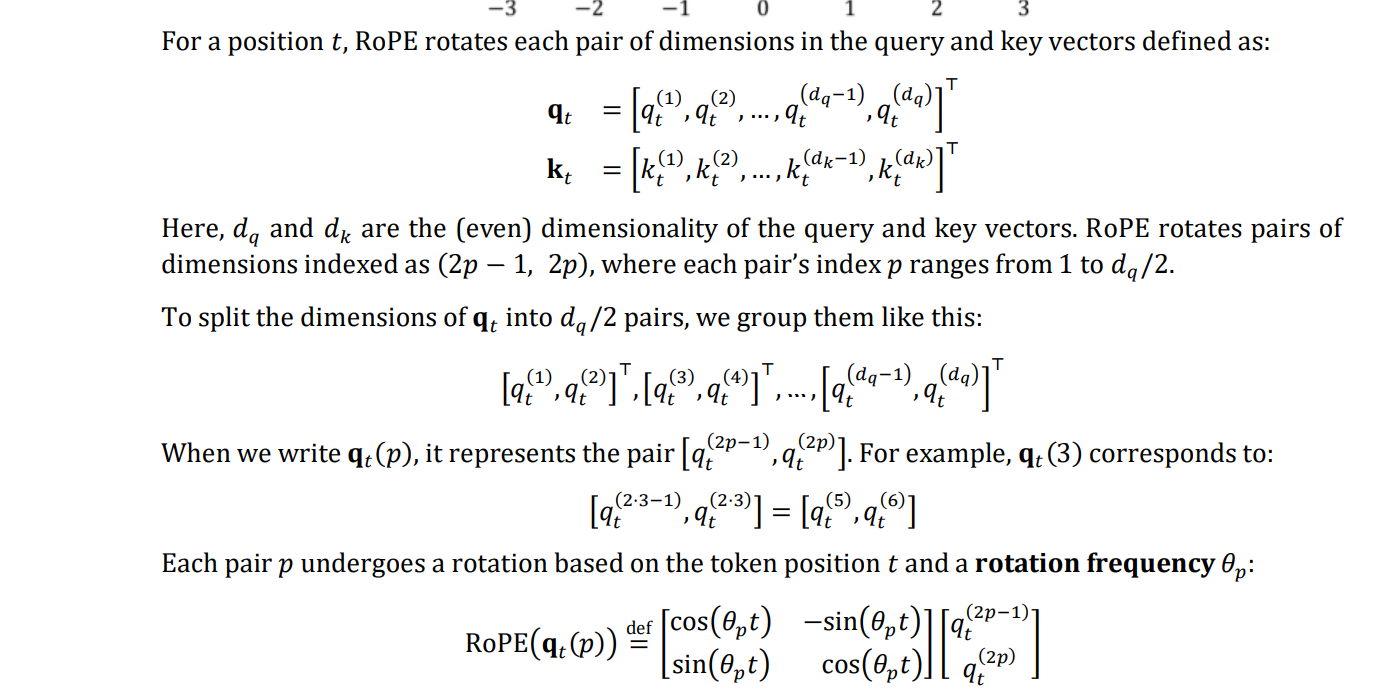
In higher dimensions, each pair gets its own position-dependent rotation.
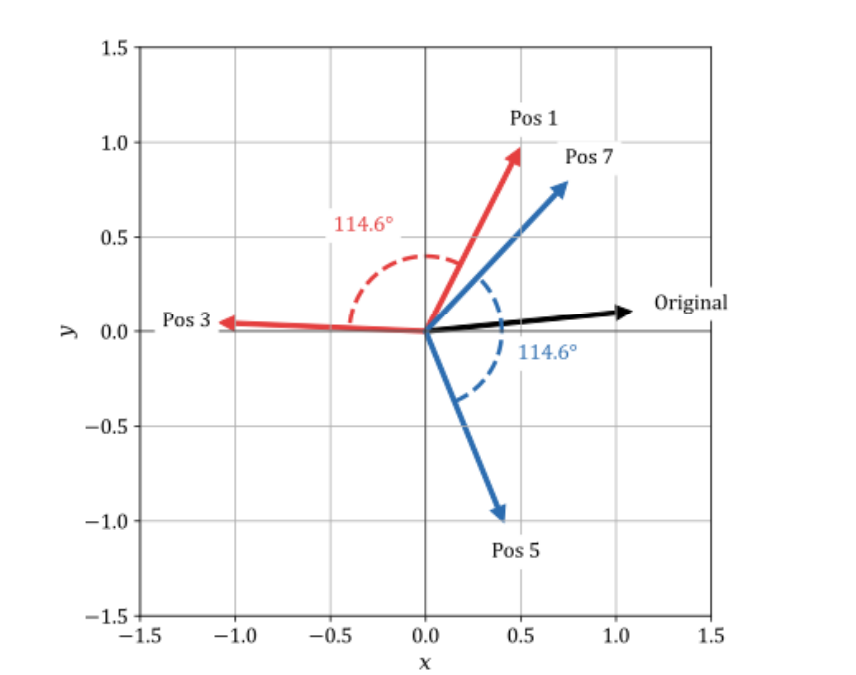
----------


"Now, *how much* do we rotate? That's where the position comes in. The ***angle of rotation*** is calculated based on two things:

1.  **The word's absolute position (`m`)**: Is it the 1st word, 5th word, 100th word?
2.  **Which dimension pair (`i`) we are rotating**: Different pairs within the embedding are rotated by different base amounts.

The formula typically looks something like `angle = m * θ_i`, where:
*   `m` is the position index (0, 1, 2...).
*   `θ_i` is a base frequency (a predefined constant) that *decreases* for later dimension pairs. Think of it like having fast-spinning pointers for early dimensions and slow-spinning pointers for later dimensions.

So, for a specific word at position `m`, each pair of dimensions `(2i, 2i+1)` in its embedding gets rotated by an angle `m * θ_i`. ***The angle directly encodes the position.***"


## 3. How the Angle Encodes Relative Position

A key property of RoPE is that **relative distances** between positions become encoded as the angles between their rotated vectors. In your diagram, the angle between the vectors at positions 1 and 3 is the same as that between 5 and 7. Both pairs are exactly two steps apart, so RoPE enforces that the rotation difference is identical.

-   For positions t1t_1 and t2t_2, the difference in rotation angles is proportional to $$ ∣t1−t2∣|t_1 - t_2|$$ .
    
-   This ensures that **attention depends on relative position**: if two tokens are equally far apart, the angular offset in their query/key vectors is the same.
    

----------

## 4. Extending to Longer Sequences

`An attractive feature of RoPE is that it generalizes well to positions **beyond** those seen in training.` With sinusoidal embeddings, you can extrapolate beyond the training range, `but the direct sine/cosine approach often degrades at positions much larger than the training context`.

> RoPE’s rotation-based mechanism tends to preserve the relative geometry more gracefully, allowing:

1.  **Training on shorter sequences** (less memory and time).
    
2.  **Inference on much longer sequences** with minimal loss of performance.
    

----------

## 5. Why It Works Well

1.  **Relative Position Matters**: In language tasks, the difference in positions often matters more than the absolute positions. RoPE directly encodes those differences in angles.
    
2.  **Smooth Extrapolation**: Because rotations compose smoothly, you can “keep rotating” for tokens far beyond your training horizon without abruptly running out of defined positional embeddings.
 

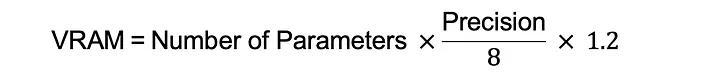

https://huggingface.co/spaces/Vokturz/can-it-run-llm

---

# Section 6: Fine-Tuning & Practical Tips

Practical guidance for fine-tuning LLMs, padding strategies, hardware requirements, optimization, and inference frameworks.

---

Yes, in the case of **Supervised Fine-Tuning (SFT) of an LLM (like GPT-2, GPT-3, or Llama),** setting the **`pad_token_id` equal to `eos_token_id`** is a common practice when padding is required.  

### ✅ **Why is this done?**  
1. **GPT-based models do not have a native `pad_token`**  
   - Unlike BERT (which has `[PAD]`), GPT-2 and similar models **do not** define a padding token.
   - However, padding is often needed for **batched training** where sequences must be the same length.
   
2. **Prevents attention to padded tokens**  
   - Setting `pad_token_id = eos_token_id` ensures that padding behaves like the end of a sequence.
   - This prevents the model from learning unnecessary dependencies on the padding tokens.

3. **Maintains consistency with causal language modeling**  
   - Since GPT-based models are trained to stop at `eos_token_id`, using it for padding keeps the logic consistent.

---

### ✅ **How to Implement This in Hugging Face Transformers?**
```python
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# Set pad_token_id to eos_token_id if not already set
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Pad Token ID:", tokenizer.pad_token_id)  # Should match eos_token_id
```

### 🚀 **When Do You Need This?**
- **Fine-tuning LLM with batch processing**
- **Training models where dynamic padding is used**
- **Handling different sequence lengths in batches efficiently**


- General Fine-tune requirements: Note: This guide is designed for consumer GPUs (24GB+) like the NVIDIA RTX 4090/5090 or A10G, but can be adapted for larger systems.


https://github.com/philschmid/deep-learning-pytorch-huggingface/tree/main

The temperature parameter in language models controls how “peaked” or “flat” the probability distribution is when sampling the next token. It's applied in the softmax operation over the model’s logits. Mathematically, for each logit $$ z_i $$, the probability is computed as:

$$
P(i) = \frac{\exp\left(\frac{z_i}{T}\right)}{\sum_j \exp\left(\frac{z_j}{T}\right)}
$$

### Why Typically Use 0–1?

- **When $$T < 1$$:**  
  The differences between logits are amplified. The softmax output becomes more concentrated on the highest-probability token, making the model more deterministic (less random).
  
- **When \(T = 1\):**  
  The model uses its natural probability distribution.
  
- **When \(T > 1\):**  
  The differences between logits are diminished, which flattens the distribution. This means even lower-probability tokens have a higher chance of being selected, leading to more diverse—but sometimes less coherent—outputs.

### Concrete Example

Suppose the logits for three possible tokens are:  
$$
\mathbf{z} = [2.0, 1.0, 0.0]
$$

**With \(T = 1\):**

\[
\begin{aligned}
\exp(2.0/1) &= e^2 \approx 7.39 \\
\exp(1.0/1) &= e^1 \approx 2.72 \\
\exp(0.0/1) &= e^0 = 1
\end{aligned}
\]

Total \(= 7.39 + 2.72 + 1 \approx 11.11\)

Probabilities:
\[
\begin{aligned}
P(1) &\approx \frac{7.39}{11.11} \approx 0.665 \\
P(2) &\approx \frac{2.72}{11.11} \approx 0.245 \\
P(3) &\approx \frac{1}{11.11} \approx 0.090
\end{aligned}
\]

**With \(T = 2\):**

\[
\begin{aligned}
\exp(2.0/2) &= e^1 \approx 2.72 \\
\exp(1.0/2) &= e^{0.5} \approx 1.65 \\
\exp(0.0/2) &= e^0 = 1
\end{aligned}
\]
Total \(= 2.72 + 1.65 + 1 \approx 5.37\)

Probabilities:
\[
\begin{aligned}
P(1) &\approx \frac{2.72}{5.37} \approx 0.507 \\
P(2) &\approx \frac{1.65}{5.37} \approx 0.307 \\
P(3) &\approx \frac{1}{5.37} \approx 0.186
\end{aligned}
\]

Here you see that with \(T = 2\) (i.e. greater than 1), the highest probability token’s likelihood drops from ~66.5% to ~50.7%, and the lower-probability tokens get a boost. This makes the model’s output more varied and creative, but it can also lead to less coherent or less predictable responses.

### In Summary

- **Temperature 0–1:** Offers control to make outputs more deterministic and focused.
- **Temperature >1:** Increases randomness by `flattening the distribution`, which can be useful for creative tasks but may harm coherence.


---

# Section 4: Quantization & Model Formats

Everything about reducing model size for deployment -- quantization techniques, data types, GGUF, and safetensors.

---

### **Understanding Quantization in LLMs: Symmetric vs. Asymmetric**  

When large language models (LLMs) undergo **quantization**, their weights and activations are mapped from high-precision formats (like **float32**) to lower-precision ones (**float16, bfloat16, int8**) to speed up inference and reduce memory usage.  

 Types of Weight Quantization

### 1. **Post-Training Quantization (PTQ)**
- **Description**: Weights from a pre-trained model are directly converted to lower precision without retraining.
- **Advantages**: Simple and easy to implement.
- **Disadvantages**: Potential performance degradation.
- **Best Use Case**: Suitable when computational resources for retraining are limited.

### 2. **Quantization-Aware Training (QAT)**
- **Description**: Quantization is performed during training or fine-tuning, allowing the model to adapt to lower precision.
- **Advantages**: Produces better performance compared to PTQ.
- **Disadvantages**: Requires additional training data and computational resources.
- **Best Use Case**: Ideal when representativ

## Data Types in Quantization

Common floating-point formats include:
- **FP32**: 32 bits; provides high precision but requires more memory.
- **FP16 (Half-Precision)**: 16 bits; reduces memory usage but has lower precision.
- **BF16 (Brain Floating-Point)**: 16 bits; prioritizes range over precision, widely supported by modern hardware like NVIDIA Ampere GPUs.

### Comparison of FP32, FP16, and BF16
- **FP32**: High precision, high memory usage.
- **FP16/BF16**: Lower precision, reduced memory footprint. BF16 is preferred for its larger range.
- **INT8 (8-bit Integer)**:Further reduces memory footprint.

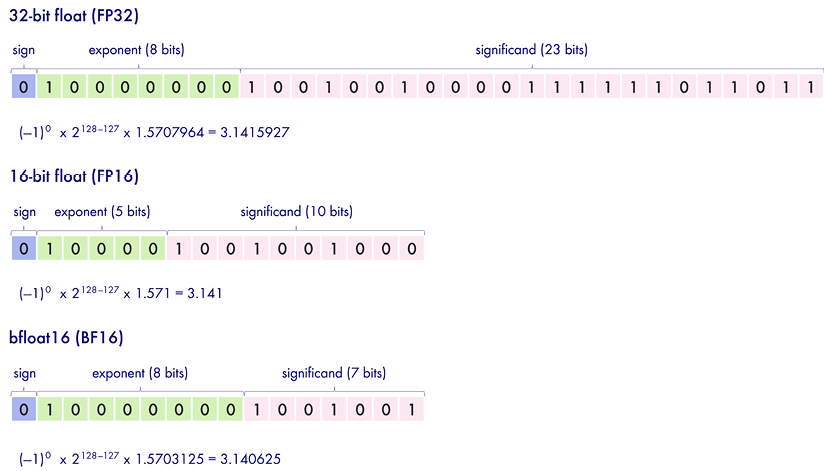


## **1️⃣ Symmetric vs. Asymmetric Quantization**
Quantization reduces precision by mapping a wide range of values into a smaller set of discrete values. The key difference between **symmetric** and **asymmetric** quantization lies in how these values are mapped.

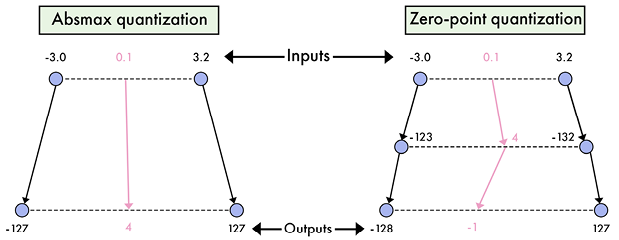 

### **🔷 Symmetric Quantization**
- The range is centered around **zero**.
- Positive and negative values are mapped **equally**.
- Represented as:  
- Used for **weight quantization** in LLMs since weights are typically **zero-mean**.
- 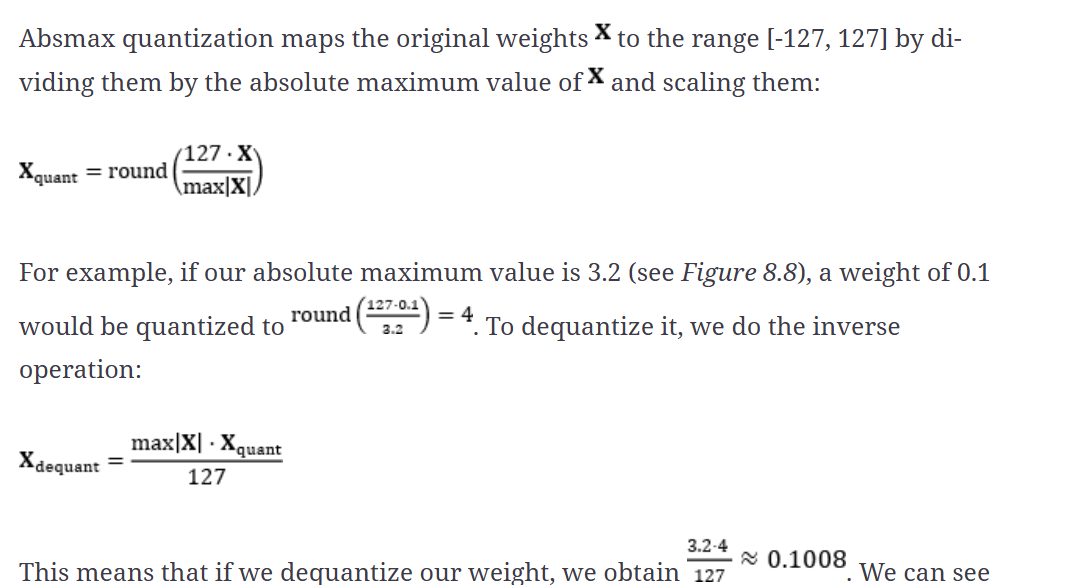
- 
✅ **Advantage**: Faster computation (hardware optimized).  
❌ **Disadvantage**: May not fully utilize the range for values that are **not zero-centered**.

- **Issue**: Smaller values (e.g., **2.38 and 34.44**) are rounded to **zero**, losing precision.

✅ **Best for**: Weight matrices in LLMs (which are zero-centered).  
❌ **Problem**: Poor representation for small-magnitude values.  


### **🔷 Asymmetric Quantization**
- Uses an **offset (zero point)** to shift the range.
- Helps in handling data with non-zero mean.
- Represented as:  
  
- Used for **activations** in LLMs, where inputs may have different dynamic ranges.
- 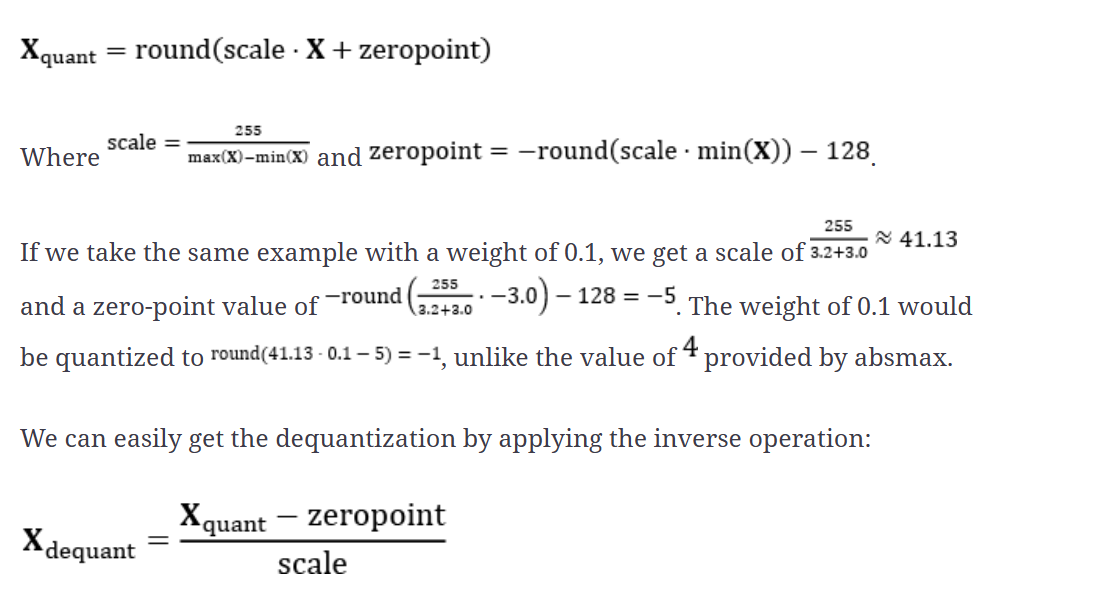

✅ **Advantage**: More efficient representation for non-zero-centered data.  
❌ **Disadvantage**: Slightly more complex computations.

---

#### **🔷 Asymmetric Quantization Results**

✅ **Best for**: Inputs/activations in LLMs (which have variable ranges).  
❌ **Problem**: Some values may shift incorrectly, causing range distortion.  

---

### **4️⃣ Conclusion**
1. **Symmetric quantization** is **simpler and faster** but loses precision for small values.  
2. **Asymmetric quantization** preserves more detail **but is more complex** and can introduce slight distortions.  
3. **In LLMs**, symmetric quantization is preferred for **weights**, while asymmetric quantization is better for **inputs/activations**.  

> `LM.int8()` employs a mixed-precision quantization scheme, `where outlier features are processed using FP16`, while the remaining values are quantized to INT8. This approach effectively reduces the memory footprint of LLMs by nearly 2x while minimizing performance degradation.
>  `NF4` is a 4-bit precision format designed for `QLoRA` (


### Quantization with GGUF and llama.cpp

#### Overview of llama.cpp
- **llama.cpp**: Open-source C++ library by Georgi Gerganov for inference with various LLMs.
- **Key Benefits**:
  - Runs on CPUs, Android devices, and general hardware (no specialized GPU needed).
  - Offloads layers to GPU to enhance speed.
  - Supports optimization techniques like FlashAttention-2 and speculative decoding.

#### GGUF Quantization Format
- **Purpose**: Simplifies and accelerates model loading for inference.
- **Supported Precision Levels**:
  - **1-Bit (IQ1_S/M)**: Low quality.
  - **2-Bit (IQ2_XXS/XS/S/M, Q2_K)**: Usable for large models, but generally low quality.
  - **3-Bit (IQ3_XXS/XS/S/M, Q3_K_S/M/L)**: Suitable for large models.
  - **4-Bit (IQ4_XS/NL, Q4_K_S/M, Q4_0/1)**: Good quality for most models.
  - **5-Bit (Q5_K_S/M, Q5_0/1)**: High quality.
  - **6-Bit (Q6_K)**: Very high quality.
  - **8-Bit (Q8_0)**: Highest quality.

#### How GGUF Works
- Values are grouped into blocks and quantized.
- **Example**:
  - Q4_0: Handles 32 values per block, scaling by the largest weight in the block.
  - Q4_K: Uses super-blocks with improved precision (e.g., scales quantized in 6 bits).
  - i-Quants: Inspired by QuIP#, balances positive/negative quant signs.

#### Practical Steps for GGUF Quantization (Example Workflow)
#### Environment Setup
1. Clone and build llama.cpp:
   ```bash
   git clone https://github.com/ggerganov/llama.cpp
   cd llama.cpp && git pull && make clean && LLAMA_CUBLAS=1 make
   pip install -r llama.cpp/requirements.txt
   ```

2. Download a model (e.g., from Hugging Face Hub):
   ```bash
   MODEL_ID="mlabonne/EvolCodeLlama-7b"
   git lfs install
   git clone https://huggingface.co/${MODEL_ID}
   ```

#### Conversion and Quantization
1. **Convert to FP16**:
   ```bash
   python llama.cpp/convert.py ${MODEL_NAME} --outtype f16 --outfile {MODEL_NAME}.fp16.bin
   ```

2. **Quantize to GGUF (e.g., Q4_K_M)**:
   ```bash
   ./llama.cpp/quantize {MODEL_NAME}.fp16.bin {MODEL_NAME}.Q4_K_M.gguf q4_k_m
   ```

#### Deployment
- Upload to Hugging Face Hub:
   ```python
   from huggingface_hub import create_repo, HfApi
   # Authenticate and upload `.gguf` files to your repository.
   ```

#### Usage
- GGUF models are compatible with:
  - **Backends**: llama-cpp-python.
  - **Frameworks**: LangChain.
  - **Frontends**: LM Studio, Text Generation Web UI.

#### Advantages of llama.cpp and GGUF
- Broad compatibility with general hardware.
- Lightweight and highly optimized for easy integration.
- Supports cutting-edge quantization techniques like FlashAttention-2.

> The  format acts as a container that efficiently stores all the crucial details of a model. Everything from the model's weights (quantized or otherwise), its architecture, and tokenizer information, to metadata like quantization parameters, model version, and usage instructions, is neatly packed into this file.



The GGUF (GGML Universal Format) is designed to store and organize important details of a machine learning model

1.  **Model Weights (Quantized or Full Precision)**
    
    -   This includes the core data tensors that the model uses for computation, such as matrices and vectors for layers, attention mechanisms, and more.
    -   The weights could be in a quantized format to save space and improve inference efficiency.
2.  **Quantization Metadata**
    
    -   Details about how the weights were quantized are stored. For example:
        -   Quantization method (e.g., per‑tensor, per‑channel, or block‑wise).
        -   Bit precision (e.g., 8‑bit, 4‑bit).
        -   Any scaling factors or zero-point values used during quantization.
3.  **Model Architecture Information**
    
    -   The layout and structure of the model are captured, such as:
        -   Number and types of layers (e.g., transformer blocks, feed-forward layers).
        -   Hyperparameters like hidden size, number of heads in attention, etc.
4.  **Tokenization Information**
    
    -   Information about the tokenizer used by the model, which includes:
        -   The vocabulary of tokens.
        -   Special tokens (e.g., start, end, padding, and unknown tokens).
        -   Byte-Pair Encoding (BPE) or other encoding rules.
5.  **Inference Parameters**
    -   Specifications that aid inference engines in handling the model:
        -   Maximum sequence length.
        -   Supported batch sizes.
        -   Computational optimizations specific to the model.
6.  **Versioning and Compatibility**
    
    -   Information about the format version (GGUF version) and compatibility notes for inference tools that load the model.
7.  **Metadata and Descriptions**
    
    -   General information such as:
        -   Model name, version, and author (if applicable).
        -   A description of what the model is designed to do.
        -   Notes about the training dataset or its intended use case.


 let’s analyze the impact of **float32, float16, bfloat16, and int8** on:  
- **Inference Time**  
- **Performance (Accuracy/Loss)**  
- **Storage Requirements**  

### **1️⃣ Model Storage Requirements**  
Llama 3.1 models have billions of parameters, and each parameter is stored in a specific precision format.  

| **Data Type** | **Bits per Parameter** | **Storage for 7B Parameters** | **Storage for 70B Parameters** |
|--------------|----------------------|-----------------------------|-----------------------------|
| **Float32**  | 32 bits (4 bytes)     | **28 GB**                   | **280 GB**                   |
| **Float16**  | 16 bits (2 bytes)     | **14 GB**                   | **140 GB**                   |
| **BFloat16** | 16 bits (2 bytes)     | **14 GB**                   | **140 GB**                   |
| **Int8**     | 8 bits (1 byte)       | **7 GB**                     | **70 GB**                     |

🔹 **Observation**:  
- **Int8 quantization reduces storage needs by 4× compared to Float32**.  
- **Float16 and Bfloat16 reduce it by 2×**, making them popular choices.  

---

### **2️⃣ Model Inference Time**  
Inference speed depends on GPU hardware and tensor precision support.  

| **Data Type** | **Relative Speed (vs. Float32)** | **Hardware Optimization** |
|--------------|---------------------------------|-------------------------|
| **Float32**  | **1× (slowest)**                | Standard GPU support    |
| **Float16**  | **2–4× faster**                 | Tensor cores optimized  |
| **BFloat16** | **2–3× faster**                 | Efficient on TPUs       |
| **Int8**     | **4–8× faster**                 | INT8 tensor cores       |

🔹 **Observation**:  
- **Float16/Bfloat16 are 2–4× faster than Float32**, commonly used in Llama models.  
- **Int8 can be up to 8× faster** but may degrade accuracy slightly.  

---

### **3️⃣ Performance (Accuracy/Loss)**  
Quantization affects model accuracy by reducing precision.  

| **Data Type** | **Accuracy Drop** | **Use Case** |
|--------------|------------------|-------------|
| **Float32**  | **0% (Full precision)** | Baseline, best accuracy |
| **Float16**  | **~0.1–0.5%** loss | Standard LLM inference |
| **BFloat16** | **~0.1–0.5%** loss | Used in TPUs, robust performance |
| **Int8**     | **~1–2% loss** | Low-latency, edge AI |

🔹 **Observation**:  
- **Float16 and Bfloat16 give near-Float32 accuracy** and are widely used in inference.  
- **Int8 may lead to noticeable performance loss** but is useful for **speed and efficiency**.  

---

### **4️⃣ Summary**
| **Metric**   | **Float32** (Baseline) | **Float16** | **BFloat16** | **Int8** |
|-------------|-----------------|----------|----------|------|
| **Storage** | 100% (Largest)   | 50%      | 50%      | 25%  |
| **Speed**   | 1× (Slow)        | 2–4×     | 2–3×     | 4–8× |
| **Accuracy**| Best (No loss)   | ~0.5% loss | ~0.5% loss | ~2% loss |

### **Final Recommendation**
- **For inference**: **Float16/Bfloat16** (good balance of speed and accuracy).  
- **For extreme efficiency**: **Int8** (best for low-memory or high-speed applications).  



> **Interview Tip -- Quantization:** When asked about quantization, structure your answer: (1) What it is (mapping FP32 to lower precision), (2) Two approaches -- PTQ vs QAT, (3) Symmetric vs Asymmetric, (4) Popular tools -- GPTQ, AWQ, llama.cpp/GGUF, bitsandbytes. Always mention the trade-off: smaller model size and faster inference at the cost of some accuracy. For a 7B model, going from FP16 to INT4 cuts VRAM from ~14GB to ~4GB.


### **🚀 Dot Product, Variance, and Softmax Gradients**

📌 **Key Takeaway**:

-   The variance of the dot product grows **linearly** with the dimension **d**.
-   If **d is large**, the dot product values become very spread out (high variance).

----------

### ** Softmax and Vanishing Gradients**

-   The Softmax function transforms the dot product into attention scores:
    
    Softmax(Si)= $$ eSi∑jeSj\text{Softmax}(S_i) = \frac{e^{S_i}}{\sum_j e^{S_j}} $$
-   If **d is large**, the dot product values **have high variance**, meaning:
    
    -   Some SiS_i will be **very large** →  $$ eSie^{S_i} $$ becomes **huge**.
    -   Some SiS_i will be **very small** → $$ eSie^{S_i} $$ becomes **tiny**.
    -   This makes Softmax **output close to 0 or 1** for many positions.

🎯 **Why is this bad?**

-   When Softmax outputs **extreme values (close to 0 or 1)**, the gradients of Softmax become **very small**.
-   This leads to the **vanishing gradient problem**, where the model struggles to update weights effectively.

----------

### ** Preventing the Vanishing Gradient Issue**

To control the variance, we use **scaling**:

S=q⋅kdS = \frac{q \cdot k}{\sqrt{d}}

This **reduces the variance** of SS to **1**, preventing Softmax from pushing values too far into extreme regions.
📌 **Final Insight**:
-   Without scaling, large d → large variance → **vanishing gradients**.
-   **Scaling by  $$ attention*a1/\sqrt{d} $$ stabilizes Softmax and helps learning.**

## inference frameworks, 
- Hugging Face’s Text Generation Inference (TGI), 
- vLLM, and 
- NVIDIA TensorRT-LLM.



### **1. Original Tensor**
Start with a tensor of numerical values. For example:
```
[0.1, -0.5, 3.2, -1.7, 0.0, 1.3]
```

---

### **2. Symmetric Quantization**
#### Step-by-Step Process:
1. **Find the Absolute Maximum**:  
   Identify the largest absolute value in the tensor (ignoring the sign).  
   Example:  
   - Absolute values: `[0.1, 0.5, 3.2, 1.7, 0.0, 1.3]`  
   - Absolute maximum: `3.2`

2. **Calculate the Scale**:  
   Use the formula:  
   ```
   Scale = 127 / Absolute Maximum
   ```  
   In this case:  
   ```
   Scale = 127 / 3.2 ≈ 39.6875
   ```

3. **Quantize the Values**:  
   Multiply each value in the tensor by the scale, then round to the nearest integer within the range [-127, 127].  
   Example:  
   - Scaled values: `[0.1*39.6875, -0.5*39.6875, 3.2*39.6875, ...]`  
   - Quantized values: `[4, -20, 127, -67, 0, 52]`

4. **Dequantize the Values**:  
   To approximate the original tensor, divide the quantized values by the same scale.  
   Example:  
   - Dequantized values: `[4/39.6875, -20/39.6875, 127/39.6875, ...]`  
   - Result: `[0.101, -0.504, 3.2, -1.688, 0.0, 1.309]`

---

### **3. Zero-Point Asymmetric Quantization**
#### Step-by-Step Process:
1. **Find the Range**:  
   Calculate the range of the tensor:  
   ```
   Range = Maximum Value - Minimum Value
   ```  
   Example:  
   - Max: `3.2`, Min: `-1.7`  
   - Range: `3.2 - (-1.7) = 4.9`

2. **Calculate the Scale**:  
   Use the formula:  
   ```
   Scale = Quantization Range (255) / Tensor Range
   ```  
   In this case:  
   ```
   Scale = 255 / 4.9 ≈ 52.04
   ```

3. **Determine Zero-Point**:  
   Offset values to fit the asymmetric range [-128, 127] by calculating:  
   ```
   Zero-Point = Round(-Scale * Min Value - 128)
   ```  
   Example:  
   ```
   Zero-Point = Round(-52.04 * -1.7 - 128) ≈ 64
   ```

4. **Quantize the Values**:  
   Apply the formula:  
   ```
   Quantized Value = Round(Original Value * Scale + Zero-Point)
   ```  
   Example:  
   - Quantized values: `[Round(0.1*52.04 + 64), Round(-0.5*52.04 + 64), ...]`  
   - Result: `[64, 37, 230, 9, 64, 132]`

5. **Dequantize the Values**:  
   To approximate the original tensor, use the formula:  
   ```
   Dequantized Value = (Quantized Value - Zero-Point) / Scale
   ```  
   Example:  
   - Dequantized values: `[(64-64)/52.04, (37-64)/52.04, ...]`  
   - Result: `[0.0, -0.519, 3.21, -1.689, 0.0, 1.308]`

---

### **Key Observations**
- **Absmax Quantization** is symmetric and simpler, but it may not account for distribution asymmetry.
- **Zero-Point Quantization** handles asymmetric ranges better, offering improved precision for outliers or skewed data.



---

# Section 5: Evaluation Metrics

Metrics for measuring LLM quality, from intrinsic measures like perplexity to retrieval-oriented metrics.

---


### Understanding Perplexity (PPL)

Perplexity (PPL) is a metric often used in Natural Language Processing (NLP) to evaluate the effectiveness of language models. 
It is essentially a way to measure `how well a model predicts a sequence of words`.
` A lower perplexity score indicates that the language model is more adept at making accurate predictions—it is "less surprised" by the word sequences it encounters.`

#### Key Points:

1.  **Definition**:
    
    -   Perplexity is the exponentiated average negative log-likelihood of a sequence of words.
    -   Mathematically, it's defined as: $$ \text{PPL} = 2^{-\frac{1}{N} \sum_{i=1}^N \log_2 P(w_i)} $$ where ( P(w_i) ) is the probability of word ( w_i ) in the sequence.
2.  **Interpretation**:
    
    -   A lower perplexity means the model assigns higher probabilities to the actual words in the sequence.
    -   In simple terms, it means the model is more "confident" in predicting the words correctly.
3.  **Usage**:
    
    -   Perplexity is mainly used to evaluate causal language models (like GPT, Mistral), which predict the next word in a sequence.
    -   It is less relevant for Masked Language Models (MLMs) like BERT, which operate differently.
4.  **Why Perplexity?**:
    
    -   It reflects the model's ability to handle real-world language. The lower the perplexity, the better the model is at understanding and predicting text.

- **Interpretation**: A lower PPL means the model is better at predicting words in a sequence.
- **Core Idea**: Perplexity reflects how "surprised" a model is by the actual word sequence.




> **Interview Tip -- Perplexity:** A common interview question is "How do you evaluate an LLM?" Perplexity is the go-to intrinsic metric for autoregressive models. Remember: PPL = 2^(cross-entropy loss). Lower is better. But always mention that perplexity alone is not sufficient -- you also need task-specific metrics (BLEU, ROUGE, human eval) and safety evaluations. Perplexity does NOT apply to BERT-style masked models.

>  you often see in online tutorials that people assign padding token to be same as the end of sentence (eos) token. `you MUST NOT do that because it will cause problem for multi-turn conversation data` (eos appears in multi places, confusing the model)

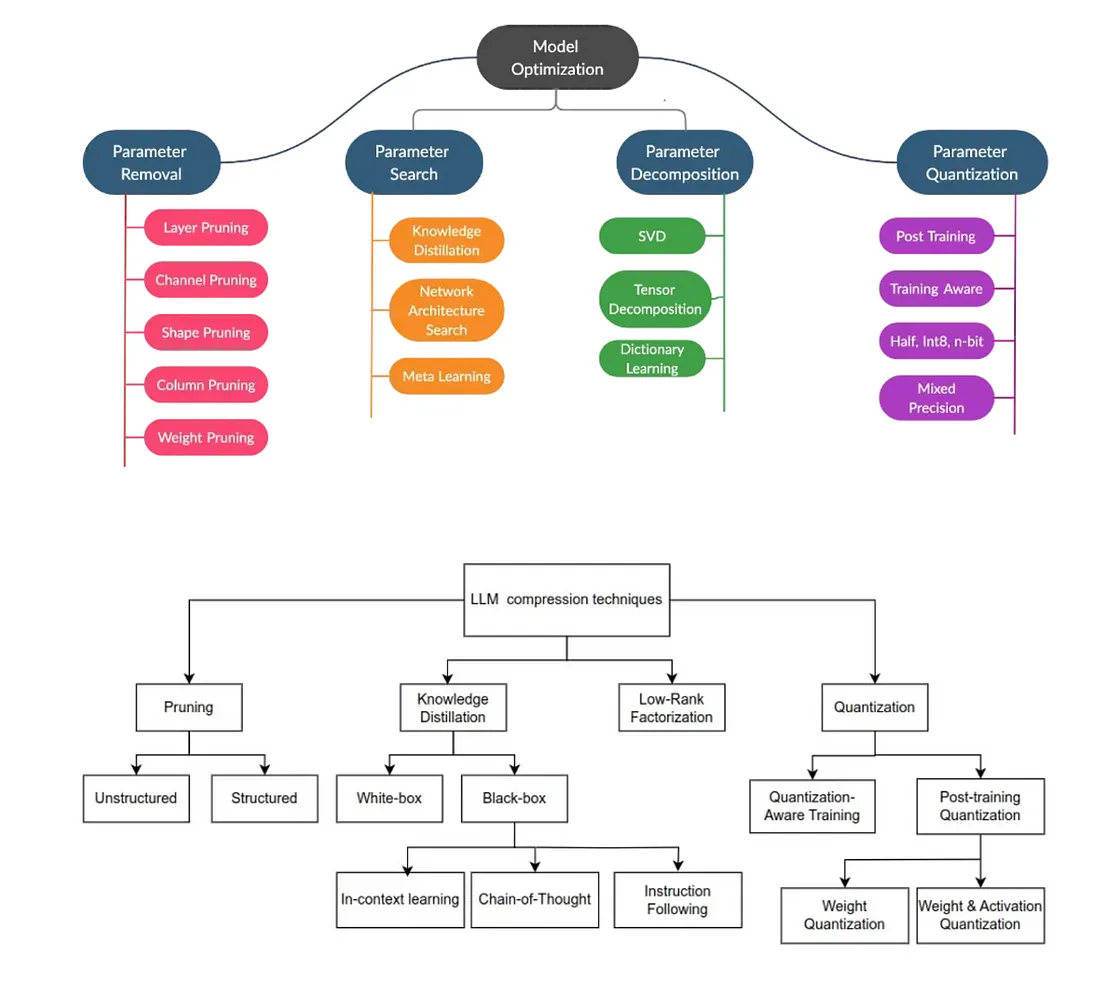


### 🔥 **Why Optimize LLMs?**  
LLMs are powerful but often **slow and resource-intensive**. Optimization helps by:  
✅ **Reducing memory usage** 📉  
✅ **Speeding up inference** ⚡  
✅ **Lowering computational costs** 💰  

---

## 🔍 **Select an Optimization Category**  

### 🏗 **1. Model Compression** – *Shrink models without losing performance*  

### 🎭 **2. Architectural Modifications** – *Efficient model structures*  

### 📚 **3. Training Strategies** – *Smarter training techniques*  

---

## 🔎 **1. Model Compression**  
**📌 Goal:** Reduce LLM size while maintaining accuracy.  

🔹 **Quantization** – Lower bit precision (e.g., 8-bit instead of 32-bit).  
&nbsp;&nbsp;&nbsp;&nbsp;✅ **Faster inference** ⚡ | ✅ **Lower memory** 📦 | ❌ *Slight accuracy loss*  
🔹 **Knowledge Distillation** – Smaller model learns from a larger model.  
&nbsp;&nbsp;&nbsp;&nbsp;✅ **Better efficiency** 🏎 | ✅ **Improved generalization** | ❌ *Relies on a good teacher model*  

🛠 **Try it out!** [Test a quantized LLM demo](#try-quantized-llm)  

---

## 🏛 **2. Architectural Modifications**  
**📌 Goal:** Optimize model structure for speed & efficiency.  

🔹 **Layer Reduction** – Fewer layers = Faster processing.  
🔹 **Efficient Attention Mechanisms** – Sparse/linear attention speeds up computations.  
🔹 **KV Cache Optimization** – Stores activations to **avoid reprocessing** long sequences.  

⚡ **Speed Boost:** **KV caching** makes long conversations feel instant!  

💡 **Want to explore?** [See efficient transformer models](#efficient-transformers)  

---

## 🎯 **3. Training Strategies**  
**📌 Goal:** Smarter ways to train models efficiently.  

🔹 **Hybrid Optimization** – Mix techniques like *Quantization + Knowledge Distillation* for balanced models.  
🔹 **RLHF & DPO** – Align models to **human preferences** using reinforcement learning.  
&nbsp;&nbsp;&nbsp;&nbsp;✅ **Improves user experience** 👤 | ❌ *Computationally expensive*  

🚀 **Want hands-on experience?** [Train a model with RLHF](#train-rlhf)  

---

## 🎯 **Quick Summary of Benefits**  

| Technique                  | 🔥 Benefits               | ⚠️ Limitations |
|----------------------------|--------------------------|----------------|
| **Quantization**          | Smaller & faster models | Accuracy drop |
| **Knowledge Distillation** | Efficient smaller models | Needs teacher model |
| **Architectural Changes**  | Efficient structures | Complexity trade-offs |
| **KV Cache Optimization** | Faster inference | Memory challenges |
| **RLHF/DPO**              | Human-aligned responses | Costly training |


Let’s optimize your AI models together! 🚀

---

# Section 3: Retrieval & Search

This section covers algorithms and metrics used in information retrieval, search engines, and ranking systems -- essential for RAG pipeline design.

---

Mean Reciprocal Rank (MRR) and Normalized Discounted Cumulative Gain (NDCG) are both evaluation metrics used to assess the performance of ranking systems, such as search engines and recommendation systems. Each metric has its own strengths and is suited for different scenarios. Here's a comparative overview:

---

### Mean Reciprocal Rank (MRR)

**Definition:** MRR measures how quickly a system returns the first relevant item in a ranked list. It is calculated as the average of the reciprocal ranks of the first relevant item across all queries.

**Formula:**
$$
\text{MRR} = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{\text{rank}_i}
$$
where $N$ is the number of queries, and $\text{rank}_i$ is the position of the first relevant item for the $i$-th query.

**Pros:**
- Simple to compute and interpret
- Emphasizes the importance of retrieving the first relevant item quickly
- Ideal for tasks where users expect a single correct answer promptly, such as question-answering systems

**Cons:**
- Ignores the relevance of items beyond the first relevant one
- Does not account for multiple relevant items in the list
- May not be suitable for applications where users are interested in exploring a list of relevant items

---

### Normalized Discounted Cumulative Gain (NDCG)

**Definition:** NDCG evaluates the ranking quality by considering the position of relevant items and their graded relevance. It discounts the gain of each relevant item based on its position in the list.

**Formula:**
$$
\text{DCG}_K = \sum_{i=1}^{K} \frac{2^{\text{rel}_i} - 1}{\log_2(i + 1)}
$$

$$
\text{NDCG}_K = \frac{\text{DCG}_K}{\text{IDCG}_K}
$$
where $\text{rel}_i$ is the relevance score of the $i$-th item, and $\text{IDCG}_K$ is the ideal DCG for the top $K$ items.

**Pros:**
- Considers the position of all relevant items in the list
- Incorporates graded relevance, allowing for varying levels of relevance
- Provides a more comprehensive evaluation of ranking quality

**Cons:**
- More complex to compute compared to MRR
- Requires predefined relevance scores for items
- Normalization can be sensitive to the choice of $K$

---

### Comparative Overview

| Feature                 | MRR                               | NDCG                                  |
|-------------------------|-----------------------------------|---------------------------------------|
| Focus                   | First relevant item               | Overall ranking quality               |
| Relevance Grading       | Binary (relevant or not)          | Graded relevance levels               |
| Position Sensitivity    | Only the first relevant item      | All relevant items, discounted by position |
| Ideal Use Case          | Tasks requiring quick retrieval of a single relevant item | Tasks where the order of multiple relevant items matters |

---

### When to Use Each Metric

- **Use MRR** when:
  - The primary goal is to retrieve the first relevant item quickly.
  - The application involves tasks like question answering or fact retrieval.

- **Use NDCG** when:
  - The ranking of multiple relevant items is important.
  - The application involves tasks like search engines or recommendation systems where users may explore a list of relevant items.

---

- https://readmedium.com/rank-aware-recsys-evaluation-metrics-5191bba16832

> **Interview Tip -- Ranking Metrics:** If asked "MRR or NDCG?", say: "MRR is best when only the first relevant result matters (e.g., QA). NDCG is better when you care about the quality and ordering of multiple results (e.g., search engines, recommendations). In RAG pipelines, both are useful -- MRR for evaluating retriever recall of the top hit, NDCG for evaluating the full ranked list passed to the generator."

---

# Quick Reference: LLM Terminology Glossary

A concise glossary of essential LLM terms for quick interview revision.

| # | Term | Definition |
|---|------|-----------|
| 1 | **Transformer** | Neural network architecture based on self-attention mechanisms, the backbone of all modern LLMs. |
| 2 | **Self-Attention** | Mechanism that allows each token in a sequence to attend to (weigh the importance of) every other token. |
| 3 | **Multi-Head Attention (MHA)** | Running multiple self-attention operations in parallel, each learning different relationship patterns. |
| 4 | **Encoder** | Transformer component that processes the full input bidirectionally to build contextual representations (used in BERT). |
| 5 | **Decoder** | Transformer component that generates output tokens autoregressively, attending only to previous tokens (used in GPT). |
| 6 | **Tokenization** | The process of splitting text into sub-word units (tokens) that the model can process, e.g., BPE, WordPiece, SentencePiece. |
| 7 | **Embedding** | A dense, fixed-dimensional vector representation of a token, sentence, or document that captures semantic meaning. |
| 8 | **Positional Encoding** | A method to inject token order information into the model, since attention itself is permutation-invariant. |
| 9 | **RoPE (Rotary Position Embedding)** | Encodes position by rotating query/key vectors, enabling relative position awareness and better length extrapolation. |
| 10 | **LayerNorm** | Normalizes activations across the feature dimension per sample using mean and variance, with learnable scale and shift. |
| 11 | **RMSNorm** | Simplified LayerNorm that normalizes by Root Mean Square only, omitting mean centering and the shift parameter. |
| 12 | **KV Cache** | Stores previously computed key and value tensors during autoregressive generation to avoid redundant computation. |
| 13 | **Temperature** | Scaling factor applied to logits before softmax; lower values make output more deterministic, higher values more random. |
| 14 | **Top-K Sampling** | Decoding strategy that samples from only the K highest-probability tokens at each step. |
| 15 | **Top-P (Nucleus) Sampling** | Decoding strategy that samples from the smallest set of tokens whose cumulative probability exceeds P. |
| 16 | **Beam Search** | Decoding strategy that maintains K best partial sequences at each step and selects the highest-scoring complete sequence. |
| 17 | **Perplexity (PPL)** | Evaluation metric measuring how "surprised" a language model is by a text sequence; lower is better. |
| 18 | **BM25** | Classic sparse retrieval algorithm that ranks documents by term frequency, inverse document frequency, and document length. |
| 19 | **MRR (Mean Reciprocal Rank)** | Ranking metric that averages the reciprocal of the rank of the first relevant result across queries. |
| 20 | **NDCG (Normalized Discounted Cumulative Gain)** | Ranking metric that evaluates result quality using graded relevance scores, discounted by position. |
| 21 | **Quantization** | Reducing numerical precision of model weights/activations (e.g., FP32 to INT8) to save memory and speed up inference. |
| 22 | **PTQ (Post-Training Quantization)** | Quantizing a pre-trained model without additional training; simple but may degrade quality. |
| 23 | **QAT (Quantization-Aware Training)** | Training/fine-tuning with simulated quantization so the model learns to compensate for reduced precision. |
| 24 | **GGUF** | Binary file format (GGML Universal Format) used by llama.cpp to store quantized model weights, architecture, and metadata. |
| 25 | **Safetensors** | A fast, safe file format by Hugging Face for storing model tensors, designed to prevent arbitrary code execution. |
| 26 | **LoRA (Low-Rank Adaptation)** | Parameter-efficient fine-tuning method that adds small trainable low-rank matrices to frozen pre-trained weights. |
| 27 | **QLoRA** | Combines 4-bit quantization (NF4) with LoRA, enabling fine-tuning of large models on consumer GPUs. |
| 28 | **Matryoshka Embeddings** | Embeddings trained so that any prefix of the vector is itself a valid, lower-dimensional embedding. |
| 29 | **Knowledge Distillation** | Training a smaller "student" model to mimic the outputs of a larger "teacher" model. |
| 30 | **RLHF (Reinforcement Learning from Human Feedback)** | Aligning model outputs with human preferences by training a reward model and using RL (e.g., PPO) to optimize against it. |

---

> **Interview Tip -- General:** When asked "What is X?" in an interview, give a one-sentence definition first, then explain why it matters and when you would use it. Interviewers value clarity and practical awareness over exhaustive detail.